## ResNet50 Model Data Processing and Model Training

### Model Specifics:

* Standard ImageNet normalization from [Hugging Face](https://huggingface.co/Lab-Rasool/RadImageNet#preprocessing)
* [ResNet50](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html) with default model weights `models.resnet50(weights=models.ResNet50_Weights.DEFAULT)`
* [Adam](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html) optimizer using all model parameters `torch.optim.Adam(model.parameters(), lr=1e-4)`
* [BCEWithLogitsLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) loss function weighted towards positive class `nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)`

**3/1/2026** Notebook updated to save model checkpoints to conduct in-depth evaluation of model.

### Import & Install Libraries

In [2]:
import sys, numpy, pandas
print(sys.executable)
print("numpy:", numpy.__version__, numpy.__file__)
print("pandas:", pandas.__version__, pandas.__file__)

/sw/pkgs/arc/python3.9-anaconda/2021.11/bin/python
numpy: 1.21.6 /home/simbody/.local/lib/python3.9/site-packages/numpy/__init__.py
pandas: 1.3.5 /home/simbody/.local/lib/python3.9/site-packages/pandas/__init__.py


In [1]:
%pip install --force-reinstall "numpy==1.21.6" "pandas==1.3.5"

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.21.6-cp39-cp39-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (15.7 MB)
  Using cached pandas-1.3.5-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (11.5 MB)
  Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: python-dateutil
    Found existing installation: python-dateutil 2.9.0.post0
    Uninstalling python-dateutil-2.9.0.post0:
      Successfully uninstalled python-dateutil-2.9.0.post0
  Attempting uninstall: numpy
    Found existing in

In [3]:
import sys
import random
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)


/home/simbody/.local/lib/python3.9/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.sparse import csr_matrix, issparse


In [4]:
!{sys.executable} -m pip install torch

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import torch
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

### Reproducability

In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

### Outcome Variable: Diagnosis

Diagnoses of interest:

* Pneumonia
* Pneumothorax

In [7]:
# CheXpert labeler contains labels at time of x-rays
chexpert_file = "/nfs/turbo/si-acastel/mimic-project/data_raw/mimic-cxr-jpg_2_1_0_gcs/mimic-cxr-2.0.0-chexpert.csv.gz"
# MIMIC-CXR official split metadata file that labels each study train/val/test
split_file = "/nfs/turbo/si-acastel/mimic-project/data_raw/mimic-cxr-jpg_2_1_0_gcs/mimic-cxr-2.0.0-split.csv.gz"


In [8]:
# Convert CheXpert label to dataframe and keep relevant columns
chex_df = pd.read_csv(chexpert_file)
chex_df = chex_df[['subject_id', 'study_id', 'Pneumothorax']].copy()

# Keep only definite labels
chex_df = chex_df[chex_df['Pneumothorax'].isin([0.0, 1.0])]
chex_df['pneumothorax'] = chex_df['Pneumothorax'].astype(int)

In [9]:
chex_df.head()

,subject_id,study_id,Pneumothorax,pneumothorax
28,10001217,58913004,1.0,1
37,10001884,50376803,0.0,0
38,10001884,50712381,0.0,0
45,10001884,53880659,0.0,0
55,10001884,56722923,0.0,0


### Grab the Images

In [10]:
images_path = Path("/nfs/turbo/si-acastel/mimic-project/data_raw/mimic-cxr-jpg_2_1_0_gcs/files")

In [11]:
records = []

for subject_dir in images_path.glob("p*/*"):  # p10/p10000032
    subject_id = int(subject_dir.name[1:])    # remove leading 'p'
    
    for study_dir in subject_dir.glob("s*"):
        study_id = int(study_dir.name[1:])    # remove leading 's'
        
        for img_file in study_dir.glob("*.jpg"):
            records.append({
                "subject_id": subject_id,
                "study_id": study_id,
                "image_path": str(img_file)
            })

In [12]:
images_df = pd.DataFrame(records)
images_df.head()

,subject_id,study_id,image_path
0,19932024,57682201,/nfs/turbo/si-acastel/mimic-project/data_raw/m...
1,19932024,55032644,/nfs/turbo/si-acastel/mimic-project/data_raw/m...
2,19932024,55032644,/nfs/turbo/si-acastel/mimic-project/data_raw/m...
3,19932024,55032644,/nfs/turbo/si-acastel/mimic-project/data_raw/m...
4,19932024,54345212,/nfs/turbo/si-acastel/mimic-project/data_raw/m...


### Merge Images with CheXpert Labels

In [13]:
# Merge with the CheXpert df
chex_img_df = images_df.merge(
    chex_df[['subject_id', 'study_id', 'pneumothorax']],
    on=['subject_id', 'study_id'],
    how='inner'
)

# Apply offical MIMIC-CXR splitting
split_df = pd.read_csv(split_file, usecols=['subject_id', 'study_id', 'split'])
split_df = split_df.drop_duplicates(subset=['subject_id', 'study_id'])

chex_img_df = chex_img_df.merge(
    split_df,
    on=['subject_id', 'study_id'],
    how='inner'
)


In [14]:
print("Total Images:", len(chex_img_df))
print("Prevalence:", chex_img_df['pneumothorax'].mean())
print("Split counts:")
print(chex_img_df['split'].value_counts(dropna=False))

Total Images: 71976
Prevalence: 0.198079915527398
Split counts:
train       70245
test         1134
validate      597
Name: split, dtype: int64


In [15]:
chex_img_df.head()

,subject_id,study_id,image_path,pneumothorax,split
0,19932024,55032644,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,validate
1,19932024,55032644,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,validate
2,19932024,55032644,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,validate
3,19932024,58958645,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,validate
4,19603559,58679271,/nfs/turbo/si-acastel/mimic-project/data_raw/m...,0,train


### Subject-wise train/val/test split

In [16]:
# Held-out test set + 5-fold subject-wise CV on non-test data
trainval_df = chex_img_df[chex_img_df['split'] != 'test'].reset_index(drop=True)
test_df = chex_img_df[chex_img_df['split'] == 'test'].reset_index(drop=True)

target_col = "pneumothorax"
group_col = "subject_id"
N_SPLITS = 5
RANDOM_STATE = 42

cv_df = trainval_df.copy()
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
fold_splits = list(sgkf.split(cv_df, y=cv_df[target_col], groups=cv_df[group_col]))

In [17]:
print(f"Train/Val samples: {len(trainval_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Train/Val prevalence: {trainval_df[target_col].mean():.4f}")
print(f"Test prevalence: {test_df[target_col].mean():.4f}")
print(f"Unique Train/Val subjects: {trainval_df[group_col].nunique():,}")
print(f"Unique Test subjects: {test_df[group_col].nunique():,}")
print(f"Folds: {len(fold_splits)}")

Train/Val samples: 70,842
Test samples: 1,134
Train/Val prevalence: 0.1992
Test prevalence: 0.1270
Unique Train/Val subjects: 18,843
Unique Test subjects: 207
Folds: 5


In [18]:
fold_rows = []
for fold, (tr_idx, va_idx) in enumerate(fold_splits, start=1):
    tr = cv_df.iloc[tr_idx]
    va = cv_df.iloc[va_idx]
    fold_rows.append({
        "fold": fold,
        "train_n": len(tr),
        "val_n": len(va),
        "train_prev": tr[target_col].mean(),
        "val_prev": va[target_col].mean(),
        "train_subjects": tr[group_col].nunique(),
        "val_subjects": va[group_col].nunique(),
    })

fold_summary_df = pd.DataFrame(fold_rows)
print(fold_summary_df[["fold", "train_n", "val_n", "train_prev", "val_prev"]].to_string(index=False))

 fold  train_n  val_n  train_prev  val_prev
    1    56177  14665    0.196753  0.208660
    2    56639  14203    0.201910  0.188481
    3    56737  14105    0.197631  0.205601
    4    57022  13820    0.198117  0.203763
    5    56793  14049    0.201662  0.189337


### Confirm No Data Leakage

In [19]:
for fold, (tr_idx, va_idx) in enumerate(fold_splits, start=1):
    train_subjects = set(cv_df.iloc[tr_idx][group_col])
    val_subjects = set(cv_df.iloc[va_idx][group_col])
    assert train_subjects.isdisjoint(val_subjects), f"Leakage detected in fold {fold}"

assert set(trainval_df[group_col]).isdisjoint(set(test_df[group_col])), "Train/Val and test subjects overlap"
print("No subject leakage detected across all folds and held-out test split.")


No subject leakage detected across all folds and held-out test split.


### Preprocessing RadImageNet

In [20]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

### Create PyTorch Dataset to be Wrapped Around [DataLoader](https://docs.pytorch.org/docs/stable/data.html)

In [21]:
class CXRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert("RGB")
        label = float(row['pneumothorax'])

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.float32)

### Setup the Model

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def build_model():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(device)


def make_pos_weight(train_df, label_col=target_col):
    pos = int((train_df[label_col] == 1).sum())
    neg = int((train_df[label_col] == 0).sum())
    value = neg / max(pos, 1)
    return torch.tensor([value], dtype=torch.float32, device=device), value

device: cuda


### Training and Evaluation

In [23]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_probs, all_y = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()
        logits = model(x).squeeze(1)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_y.append(y.detach().cpu().numpy())

    y_true = np.concatenate(all_y)
    y_prob = np.concatenate(all_probs)

    return {
        "loss": total_loss / len(loader.dataset),
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "prevalence": float(y_true.mean()),
    }


def evaluate(model, loader, device, criterion=None):
    model.eval()
    all_probs, all_y = [], []
    total_loss = 0.0
    n_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float()

            logits = model(x).squeeze(1)

            # If a loss function is provided, accumulate validation loss
            if criterion is not None:
                loss = criterion(logits, y)
                total_loss += loss.item() * x.size(0)
                n_samples += x.size(0)

            probs = torch.sigmoid(logits)

            all_probs.append(probs.cpu().numpy())
            all_y.append(y.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_prob = np.concatenate(all_probs)

    result = {
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
        "prevalence": float(y_true.mean()),
        "y_true": y_true,
        "y_prob": y_prob,
    }

    # Only add loss if we actually computed it
    if criterion is not None and n_samples > 0:
        result["loss"] = total_loss / n_samples

    return result

### Training Loop & Save Best Model and Metrics

In [24]:
# training loop parameters
BATCH_SIZE = 32
NUM_WORKERS = 4
PIN_MEMORY = True
EPOCHS = 3

# Artifacts for Grad-CAM-only workflow
CHECKPOINT_DIR = Path('checkpoints_resnet50_pneumothorax')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
TEST_MANIFEST_PATH = Path('resnet50_pneumothorax_test_manifest.csv')
TEST_THRESHOLD_PATH = Path('resnet50_pneumothorax_test_threshold.txt')


In [25]:
history = []
fold_best_metrics = []
oof_rows = []
test_fold_probs = []
test_true = None

test_ds = CXRDataset(test_df, transform=preprocess)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
has_test_set = len(test_ds) > 0

for fold, (tr_idx, va_idx) in enumerate(fold_splits, start=1):
    print(f"\n===== Fold {fold}/{N_SPLITS} =====")

    train_df = cv_df.iloc[tr_idx].reset_index(drop=True)
    val_df = cv_df.iloc[va_idx].reset_index(drop=True)

    train_ds = CXRDataset(train_df, transform=preprocess)
    val_ds = CXRDataset(val_df, transform=preprocess)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True, pin_memory=PIN_MEMORY)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False, pin_memory=PIN_MEMORY)

    model = build_model()
    pos_weight_t, pos_weight_value = make_pos_weight(train_df, label_col=target_col)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    best_auprc = -1.0
    best_state = None
    best_val_pred = None

    for epoch in range(1, EPOCHS + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, device, criterion=criterion)

        history.append({
        "fold": fold,
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_auroc": train_metrics["auroc"],
        "train_auprc": train_metrics["auprc"],
        "val_loss": val_metrics["loss"],
        "val_auroc": val_metrics["auroc"],
        "val_auprc": val_metrics["auprc"],
        "pos_weight": pos_weight_value,
        })

        print(
        f"Fold {fold} | Epoch {epoch}/{EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"train_auroc={train_metrics['auroc']:.4f} | train_auprc={train_metrics['auprc']:.4f} | "
        f"val_auroc={val_metrics['auroc']:.4f} | val_auprc={val_metrics['auprc']:.4f}"
        )

        if val_metrics["auprc"] > best_auprc:
            best_auprc = val_metrics["auprc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_val_pred = (val_metrics["y_true"], val_metrics["y_prob"])

    if best_state is not None:
        model.load_state_dict(best_state)
        ckpt_path = CHECKPOINT_DIR / f"resnet50_pneumothorax_fold{fold}_best.pth"
        torch.save(best_state, ckpt_path)
        print(f"Saved checkpoint: {ckpt_path}")

    fold_eval = evaluate(model, val_loader, device)
    fold_best_metrics.append({
        "fold": fold,
        "val_auroc": fold_eval["auroc"],
        "val_auprc": fold_eval["auprc"],
        "val_prevalence": fold_eval["prevalence"],
    })

    if best_val_pred is not None:
        y_true_fold, y_prob_fold = best_val_pred
        for yt, yp in zip(y_true_fold, y_prob_fold):
            oof_rows.append({"fold": fold, "y_true": int(yt), "y_prob": float(yp)})

    if has_test_set:
        test_eval = evaluate(model, test_loader, device)
        test_fold_probs.append(test_eval["y_prob"])
        if test_true is None:
            test_true = test_eval["y_true"]
        else:
            assert np.array_equal(test_true, test_eval["y_true"]), "Test label order mismatch across folds"

history_df = pd.DataFrame(history)
fold_metrics_df = pd.DataFrame(fold_best_metrics)
oof_df = pd.DataFrame(oof_rows)

if test_true is not None and len(test_fold_probs) > 0:
    test_prob_mean = np.mean(np.stack(test_fold_probs, axis=0), axis=0)
    test_pred_df = pd.DataFrame({"y_true": test_true.astype(int), "y_prob": test_prob_mean})
else:
    test_pred_df = pd.DataFrame(columns=["y_true", "y_prob"])

# Save files used by Grad-CAM-only notebook
test_manifest_df = test_df[['image_path', 'pneumothorax']].reset_index(drop=True).copy()

history_df.to_csv("resnet50_pneumothorax_cv_history.csv", index=False)
fold_metrics_df.to_csv("resnet50_pneumothorax_cv_fold_metrics.csv", index=False)
oof_df.to_csv("resnet50_pneumothorax_cv_oof_predictions.csv", index=False)
test_pred_df.to_csv("resnet50_pneumothorax_cv_test_predictions.csv", index=False)
test_manifest_df.to_csv(TEST_MANIFEST_PATH, index=False)

print("\nSaved:")
print("- resnet50_pneumothorax_cv_history.csv")
print("- resnet50_pneumothorax_cv_fold_metrics.csv")
print("- resnet50_pneumothorax_cv_oof_predictions.csv")
print("- resnet50_pneumothorax_cv_test_predictions.csv")
print(f"- {TEST_MANIFEST_PATH}")
print(f"- checkpoints in {CHECKPOINT_DIR}")



===== Fold 1/5 =====
Fold 1 | Epoch 1/3 | train_loss=0.9518 | val_loss=0.9310 | train_auroc=0.7467 | train_auprc=0.4719 | val_auroc=0.7774 | val_auprc=0.5323
Fold 1 | Epoch 2/3 | train_loss=0.8072 | val_loss=1.0551 | train_auroc=0.8321 | train_auprc=0.6234 | val_auroc=0.7940 | val_auprc=0.5643
Fold 1 | Epoch 3/3 | train_loss=0.6334 | val_loss=1.0236 | train_auroc=0.9025 | train_auprc=0.7545 | val_auroc=0.7826 | val_auprc=0.5635
Saved checkpoint: checkpoints_resnet50_pneumothorax/resnet50_pneumothorax_fold1_best.pth

===== Fold 2/5 =====
Fold 2 | Epoch 1/3 | train_loss=0.9415 | val_loss=0.8668 | train_auroc=0.7498 | train_auprc=0.4835 | val_auroc=0.7838 | val_auprc=0.5309
Fold 2 | Epoch 2/3 | train_loss=0.7923 | val_loss=0.8623 | train_auroc=0.8368 | train_auprc=0.6366 | val_auroc=0.7863 | val_auprc=0.5313
Fold 2 | Epoch 3/3 | train_loss=0.6110 | val_loss=0.9772 | train_auroc=0.9085 | train_auprc=0.7731 | val_auroc=0.7722 | val_auprc=0.5178
Saved checkpoint: checkpoints_resnet50_pneumo

### Evaluation on Test Set

In [26]:
print("Fold-level validation metrics:")
print(fold_metrics_df.to_string(index=False))

print("\nCross-validation summary (mean +/- std):")
print(f"AUROC: {fold_metrics_df['val_auroc'].mean():.4f} +/- {fold_metrics_df['val_auroc'].std(ddof=1):.4f}")
print(f"AUPRC: {fold_metrics_df['val_auprc'].mean():.4f} +/- {fold_metrics_df['val_auprc'].std(ddof=1):.4f}")

# Choose threshold from OOF predictions by maximizing F1
if oof_df.empty:
    test_threshold = 0.5
    print("\nOOF predictions are empty; falling back to threshold=0.5")
else:
    y_oof = oof_df["y_true"].to_numpy()
    p_oof = oof_df["y_prob"].to_numpy()

    thresholds = np.linspace(0.05, 0.95, 37)
    f1s = [f1_score(y_oof, (p_oof >= t).astype(int)) for t in thresholds]
    test_threshold = float(thresholds[int(np.argmax(f1s))])

    print(f"\nSelected threshold from OOF (max F1): {test_threshold:.2f}")
    print(f"Best OOF F1: {max(f1s):.4f}")

TEST_THRESHOLD_PATH.write_text(str(test_threshold), encoding='utf-8')
print(f"Saved threshold file: {TEST_THRESHOLD_PATH}")

if test_pred_df.empty:
    print("\nTest prediction dataframe is empty. Confirm test split loading and rerun training.")
else:
    y_test = test_pred_df["y_true"].to_numpy()
    p_test = test_pred_df["y_prob"].to_numpy()
    y_pred = (p_test >= test_threshold).astype(int)

    print("\nEvaluation on Test Set:")
    print("Test prevalence:", y_test.mean())
    print("Test AUROC:", roc_auc_score(y_test, p_test))
    print("Test AUPRC:", average_precision_score(y_test, p_test))
    print("Test precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Test recall:", recall_score(y_test, y_pred, zero_division=0))
    print("Test accuracy:", accuracy_score(y_test, y_pred))
    print("Test F1:", f1_score(y_test, y_pred, zero_division=0))


Fold-level validation metrics:
 fold  val_auroc  val_auprc  val_prevalence
    1   0.794030   0.564259        0.208660
    2   0.786306   0.531333        0.188481
    3   0.789500   0.567240        0.205601
    4   0.787601   0.551276        0.203763
    5   0.787447   0.557944        0.189337

Cross-validation summary (mean +/- std):
AUROC: 0.7890 +/- 0.0030
AUPRC: 0.5544 +/- 0.0143

Selected threshold from OOF (max F1): 0.62
Best OOF F1: 0.5081
Saved threshold file: resnet50_pneumothorax_test_threshold.txt

Evaluation on Test Set:
Test prevalence: 0.12698412698412698
Test AUROC: 0.7839927048260381
Test AUPRC: 0.37424264392821127
Test precision: 0.37089201877934275
Test recall: 0.5486111111111112
Test accuracy: 0.8245149911816578
Test F1: 0.4425770308123249


### Plot AUROC and AUPRC

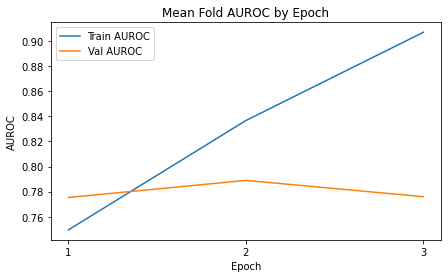

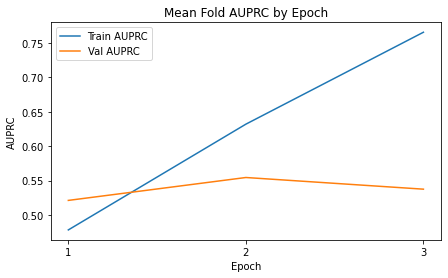

In [27]:
epoch_summary = history_df.groupby("epoch", as_index=False).agg(
    train_auroc=("train_auroc", "mean"),
    val_auroc=("val_auroc", "mean"),
    train_auprc=("train_auprc", "mean"),
    val_auprc=("val_auprc", "mean"),
)

plt.figure(figsize=(7, 4))
plt.plot(epoch_summary["epoch"], epoch_summary["train_auroc"], label="Train AUROC")
plt.plot(epoch_summary["epoch"], epoch_summary["val_auroc"], label="Val AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("Mean Fold AUROC by Epoch")
plt.xticks(epoch_summary["epoch"])
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epoch_summary["epoch"], epoch_summary["train_auprc"], label="Train AUPRC")
plt.plot(epoch_summary["epoch"], epoch_summary["val_auprc"], label="Val AUPRC")
plt.xlabel("Epoch")
plt.ylabel("AUPRC")
plt.title("Mean Fold AUPRC by Epoch")
plt.xticks(epoch_summary["epoch"])
plt.legend()
plt.show()

### Confusion Matrix

Consider choosing a classification threshold for the confusion matrix based on data and business needs. See [Google](https://developers.google.com/machine-learning/crash-course/classification/thresholding) and [Medium](https://medium.com/acorns-data-blog/choosing-the-right-model-threshold-a91bc48f354#9a4f) for more on thresholds.

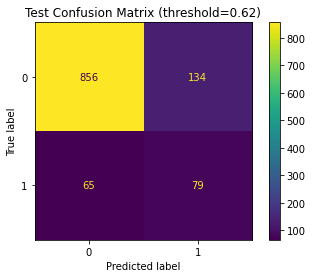

In [28]:
if test_pred_df.empty:
    print("Test prediction dataframe is empty. Confirm test split loading and rerun training.")
else:
    y_test = test_pred_df["y_true"].to_numpy()
    p_test = test_pred_df["y_prob"].to_numpy()
    y_pred = (p_test >= test_threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Test Confusion Matrix (threshold={test_threshold:.2f})")
    plt.show()
